In [34]:
import pandas as pd
import numpy as np

# 读取数据集
df = pd.read_csv(r"C:\DeskTop\小学期-机器学习\US-pumpkins.csv")

# 查看数据集的基本信息
df.shape

(1757, 26)

In [35]:
df.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [36]:
# 检查缺失值情况
missing_values = df.isnull().sum()
print("\n各列缺失值数量：")
print(missing_values[missing_values > 0])


各列缺失值数量：
Type               1712
Variety               5
Sub Variety        1461
Grade              1757
Mostly Low          103
Mostly High         103
Origin                3
Origin District    1626
Item Size           279
Color               616
Environment        1757
Unit of Sale       1595
Quality            1757
Condition          1757
Appearance         1757
Storage            1757
Crop               1757
Trans Mode         1757
Unnamed: 24        1757
Unnamed: 25        1654
dtype: int64


In [38]:
# 将价格列转换为数值类型（去除美元符号并转换为浮点数）
price_columns = ['Low Price', 'High Price', 'Mostly Low', 'Mostly High']
for col in price_columns:
    df[col] = df[col].replace({'\$': '', ',': ''}, regex=True).astype(float)

# 将日期列转换为日期类型
df['Date'] = pd.to_datetime(df['Date'])


选择High Price作为目标变量进行预测建模

特征编码后维度：(1757, 73)


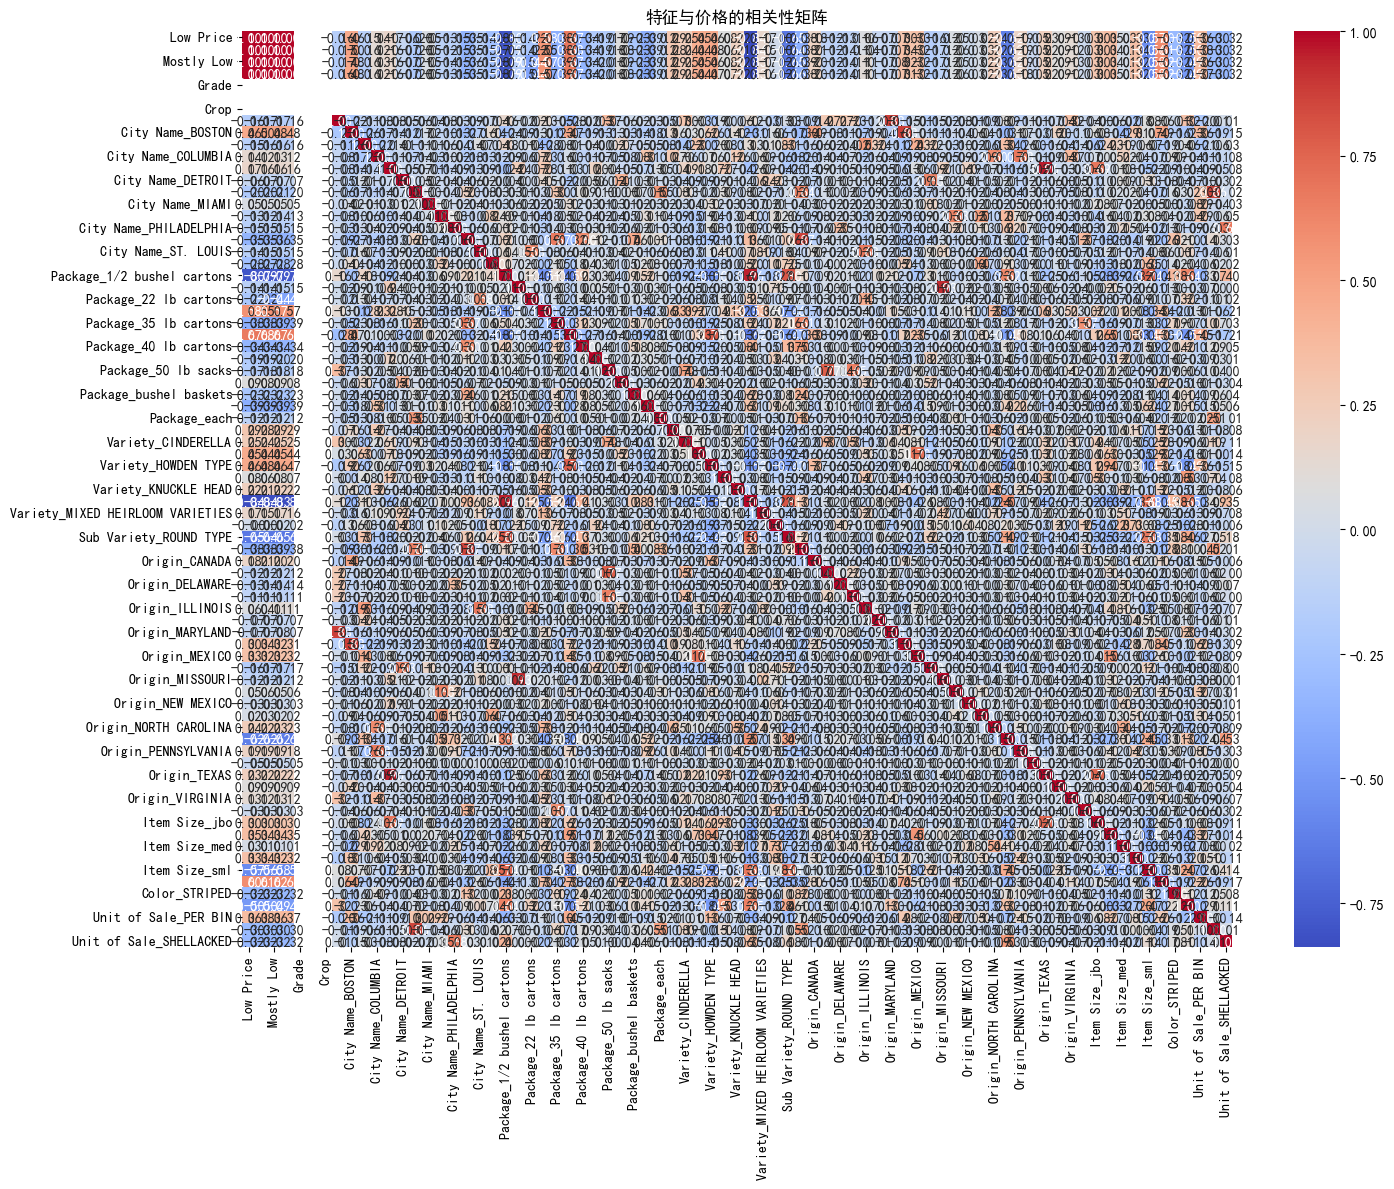

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 提取特征和目标变量
features = df[['City Name', 'Type', 'Package', 'Variety', 'Sub Variety', 'Grade', 'Origin', 'Item Size', 'Color', 'Environment', 'Unit of Sale', 'Crop']]
target = df[price_columns]

# 问题构建：确定预测目标
print("\n选择High Price作为目标变量进行预测建模")
target_column = 'High Price'

# 将分类变量转换为数值类型（独热编码）
features_encoded = pd.get_dummies(features, drop_first=True)
print(f"\n特征编码后维度：{features_encoded.shape}")

# 合并特征和目标变量
data_encoded = pd.concat([features_encoded, target], axis=1)

# 计算相关性矩阵
corr_matrix = data_encoded.corr()

# 绘制相关性热力图
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix[price_columns + features_encoded.columns.tolist()].corr(), 
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('特征与价格的相关性矩阵')
plt.tight_layout()
plt.show()

In [42]:
# 查找与High Price相关性强的特征（绝对值大于0.3）
strong_corr_features = corr_matrix[corr_matrix[target_column].abs() > 0.3].drop(price_columns, axis=0)
strong_corr_features = strong_corr_features[strong_corr_features[target_column].abs() > 0.3]
print(f"\n与{target_column}强相关的特征（相关性绝对值>0.3）：")
print(strong_corr_features[[target_column]].sort_values(by=target_column, ascending=False))


与High Price强相关的特征（相关性绝对值>0.3）：
                            High Price
Package_36 inch bins          0.433154
Package_24 inch bins          0.337257
City Name_BOSTON              0.303481
Package_1/2 bushel cartons   -0.504620
Variety_MINIATURE            -0.544909


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 提取强相关特征
selected_features = strong_corr_features.index.tolist()
X = data_encoded[selected_features]
y = data_encoded[target_column]

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\n训练集大小：{X_train.shape}, 测试集大小：{X_test.shape}")

# 数据标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


训练集大小：(1405, 5), 测试集大小：(352, 5)


In [44]:
from sklearn.ensemble import RandomForestRegressor

# 模型构建与评估

# 1. 随机森林回归模型
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [45]:
from sklearn.linear_model import LinearRegression

# 2. 线性回归模型
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [46]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 模型评估函数
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    # 训练集预测
    y_train_pred = model.predict(X_train)
    # 测试集预测
    y_test_pred = model.predict(X_test)
    
    # 计算评估指标
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    print(f"\n{model_name} 评估结果：")
    print(f"训练集 MSE: {train_mse:.4f}")
    print(f"测试集 MSE: {test_mse:.4f}")
    print(f"训练集 MAE: {train_mae:.4f}")
    print(f"测试集 MAE: {test_mae:.4f}")
    print(f"训练集 R²: {train_r2:.4f}")
    print(f"测试集 R²: {test_r2:.4f}")
    
    return y_test_pred


In [47]:
# 评估随机森林模型
rf_pred = evaluate_model(rf_model, X_train_scaled, y_train, X_test_scaled, y_test, "随机森林回归")

# 评估线性回归模型
lr_pred = evaluate_model(lr_model, X_train_scaled, y_train, X_test_scaled, y_test, "线性回归")


随机森林回归 评估结果：
训练集 MSE: 2382.8035
测试集 MSE: 2650.8272
训练集 MAE: 31.2710
测试集 MAE: 33.2069
训练集 R²: 0.6973
测试集 R²: 0.6892

线性回归 评估结果：
训练集 MSE: 2577.0210
测试集 MSE: 2961.5106
训练集 MAE: 33.7245
测试集 MAE: 36.0130
训练集 R²: 0.6726
测试集 R²: 0.6528


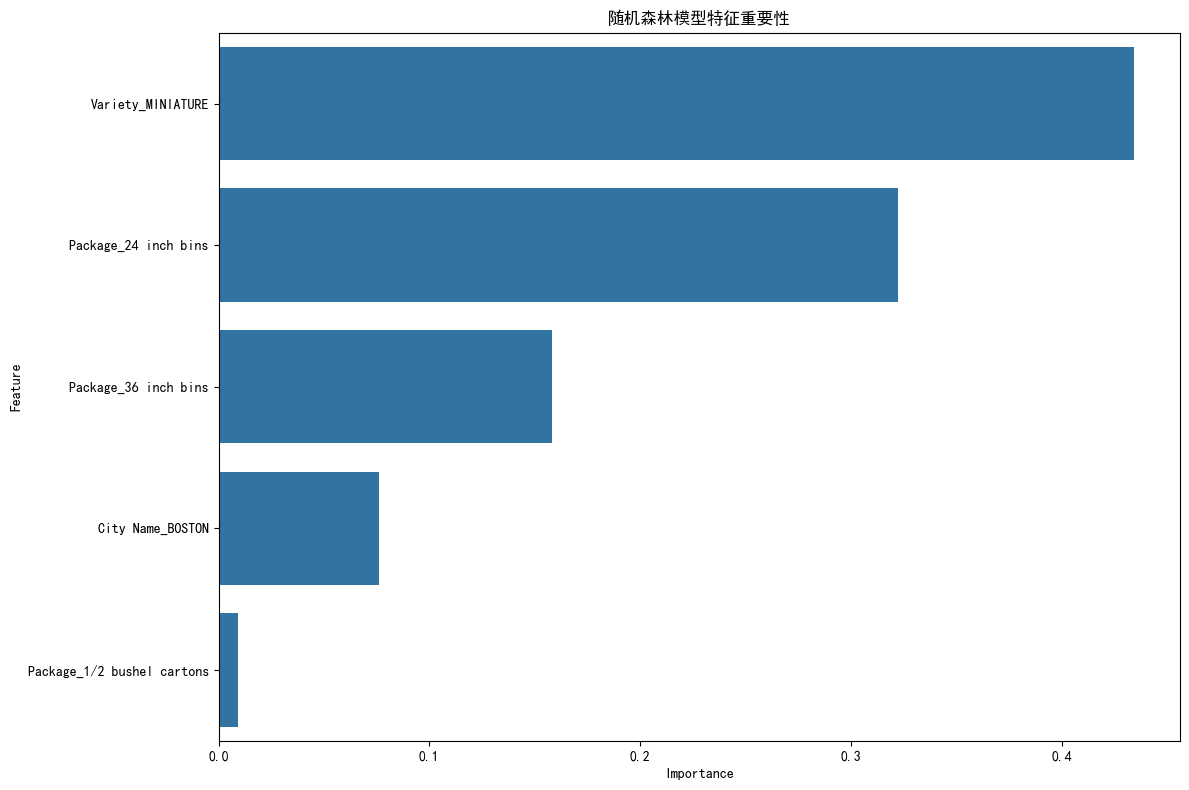


特征重要性排名（前10）：
                      Feature  Importance
4           Variety_MINIATURE    0.434284
2        Package_24 inch bins    0.322417
3        Package_36 inch bins    0.158116
0            City Name_BOSTON    0.075912
1  Package_1/2 bushel cartons    0.009270


In [48]:
# 特征重要性分析（随机森林模型）
if hasattr(rf_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': selected_features,
        'Importance': rf_model.feature_importances_
    })
    feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
    plt.title('随机森林模型特征重要性')
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    plt.show()
    
    print("\n特征重要性排名（前10）：")
    print(feature_importance.head(10))

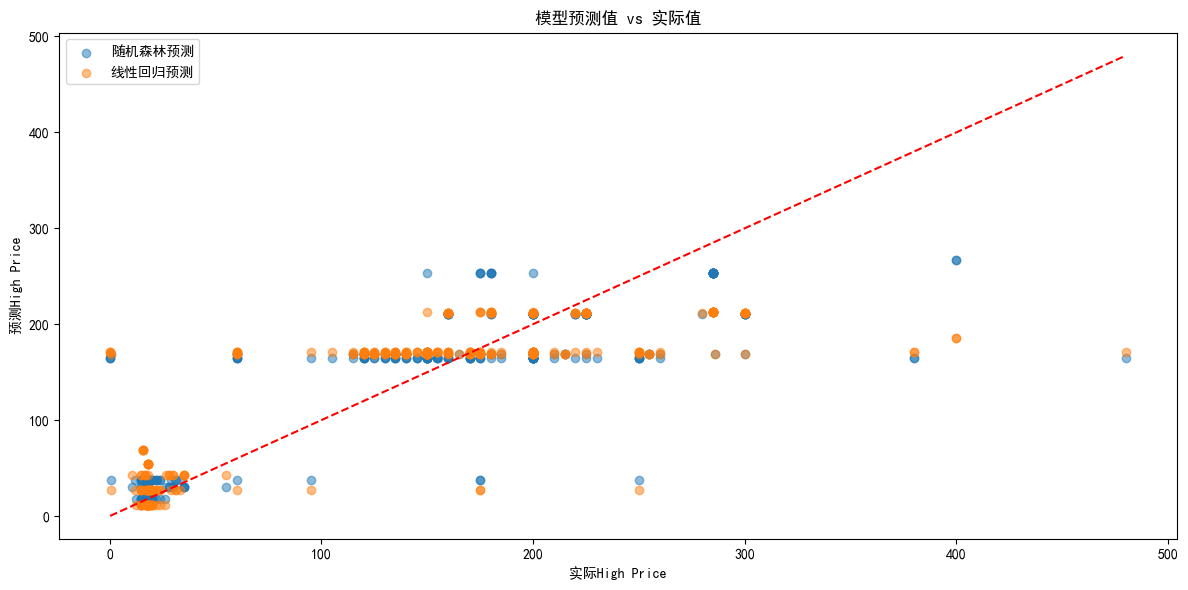

In [49]:
# 模型预测可视化
plt.figure(figsize=(12, 6))
plt.scatter(y_test, rf_pred, alpha=0.5, label='随机森林预测')
plt.scatter(y_test, lr_pred, alpha=0.5, label='线性回归预测')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel(f'实际{target_column}')
plt.ylabel(f'预测{target_column}')
plt.title(f'模型预测值 vs 实际值')
plt.legend()
plt.tight_layout()
plt.savefig('prediction_vs_actual.png')
plt.show()

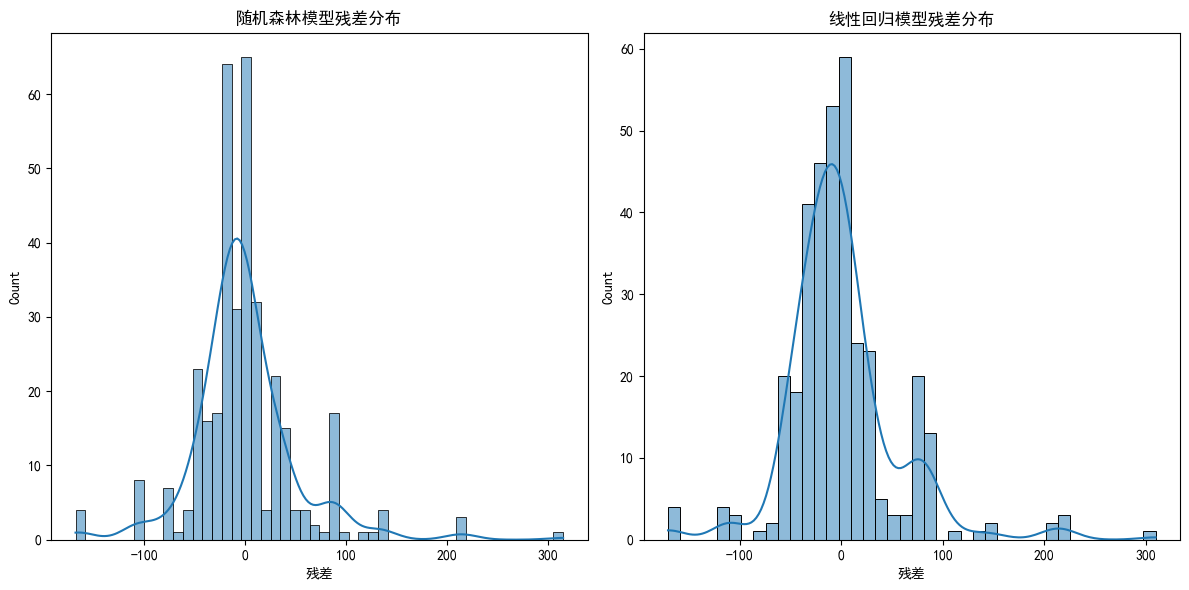

In [50]:
# 残差分析
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
residuals = y_test - rf_pred
sns.histplot(residuals, kde=True)
plt.title('随机森林模型残差分布')
plt.xlabel('残差')

plt.subplot(1, 2, 2)
residuals = y_test - lr_pred
sns.histplot(residuals, kde=True)
plt.title('线性回归模型残差分布')
plt.xlabel('残差')

plt.tight_layout()
plt.savefig('residual_distribution.png')
plt.show()

In [51]:
from sklearn.model_selection import GridSearchCV
# 超参数调优（随机森林）
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grid_search.fit(X_train_scaled, y_train)

print("\n随机森林超参数调优最佳参数：")
print(grid_search.best_params_)
print(f"最佳交叉验证得分：{grid_search.best_score_:.4f}")


随机森林超参数调优最佳参数：
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
最佳交叉验证得分：0.6868


In [52]:
# 使用最佳参数的模型评估
best_rf_model = grid_search.best_estimator_
best_rf_pred = best_rf_model.predict(X_test_scaled)
print("\n最佳参数随机森林模型评估：")
print(f"测试集 MSE: {mean_squared_error(y_test, best_rf_pred):.4f}")
print(f"测试集 MAE: {mean_absolute_error(y_test, best_rf_pred):.4f}")
print(f"测试集 R²: {r2_score(y_test, best_rf_pred):.4f}")


最佳参数随机森林模型评估：
测试集 MSE: 2657.7561
测试集 MAE: 33.2383
测试集 R²: 0.6884
